# Sesión 1 - Fundamentos de Machine Learning

**Objetivo**
- Entender qué es Machine Learning en la práctica
- Identificar features y target
- Ejecutar un pipeline básico
- Interpretar resultados

**Regla importante:** no ejecutes sin pensar. Responde primero en tu hoja de reporte.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

Matplotlib is building the font cache; this may take a moment.


## 1. Cargar dataset
Puedes reemplazar el dataset por otro si lo deseas.

In [2]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
df = pd.read_csv(url)
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## 2. Exploración inicial

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    str    
 3   smoker      244 non-null    str    
 4   day         244 non-null    str    
 5   time        244 non-null    str    
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), str(4)
memory usage: 13.5 KB


In [4]:
df.describe(include="all")

,total_bill,tip,sex,smoker,day,time,size
count,244.000000,244.000000,244,244,244,244,244.000000
unique,NaN,NaN,2,2,4,2,NaN
top,NaN,NaN,Male,No,Sat,Dinner,NaN
freq,NaN,NaN,157,151,87,176,NaN
mean,19.785943,2.998279,NaN,NaN,NaN,NaN,2.569672
std,8.902412,1.383638,NaN,NaN,NaN,NaN,0.951100
min,3.070000,1.000000,NaN,NaN,NaN,NaN,1.000000
25%,13.347500,2.000000,NaN,NaN,NaN,NaN,2.000000
50%,17.795000,2.900000,NaN,NaN,NaN,NaN,2.000000
75%,24.127500,3.562500,NaN,NaN,NaN,NaN,3.000000


## 3. Definir el problema

Vamos a intentar predecir la variable `total_bill`.

Antes de seguir, responde en tu hoja:
1. ¿Este problema es de regresión, clasificación o no supervisado?
2. ¿Por qué?

In [15]:
features = ["size", "tip"]
target = "total_bill"

X = df[features]
y = df[target]

## 4. Separación de datos

Antes de ejecutar, responde en tu hoja:
1. ¿Por qué no usamos todos los datos para entrenar?
2. ¿Qué ventaja tiene separar entrenamiento y prueba?

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## 5. Entrenar el modelo

In [17]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## 6. Hacer predicciones

In [18]:
predictions = model.predict(X_test)

results = pd.DataFrame({
    "Real": y_test,
    "Prediccion": predictions
})

results.head(10)

,Real,Prediccion
24,19.82,18.779857
6,8.77,15.165722
153,24.55,21.155856
211,25.89,30.834387
198,13.00,15.165722
176,17.89,15.165722
192,28.44,16.880905
124,12.48,16.758392
9,14.78,18.932998
101,15.38,18.228548


## 7. Visualización rápida

ValueError: x and y must be the same size

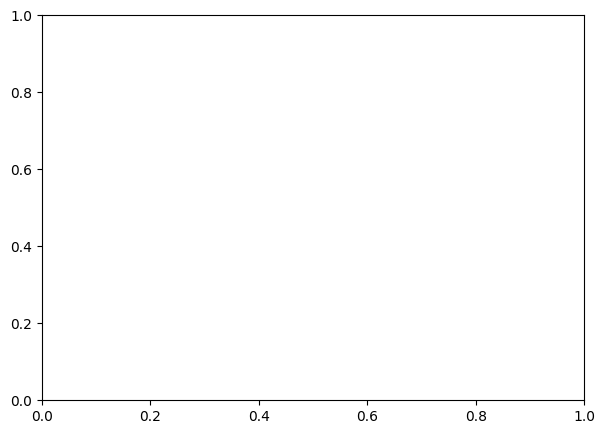

In [19]:
plt.figure(figsize=(7,5))
plt.scatter(X_test, y_test, label="Real")
plt.scatter(X_test, predictions, label="Prediccion")
plt.xlabel("Size")
plt.ylabel("Total Bill")
plt.legend()
plt.show()

## 8. Experimento

Prueba ahora con más variables. Por ejemplo:
- `["size", "tip"]`
- `["size", "tip", "day"]` (esto requeriría preparar datos categóricos)
- o cualquier otra combinación razonable

Documenta tus observaciones en tu hoja de reporte.

In [ ]:
features = ["size", "tip", "day"]

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)
predictions = model.predict(X_test)

results = pd.DataFrame({
    "Real": y_test,
    "Prediccion": predictions
})

results.head(10)

,Real,Prediccion
24,19.82,18.779857
6,8.77,15.165722
153,24.55,21.155856
211,25.89,30.834387
198,13.00,15.165722
176,17.89,15.165722
192,28.44,16.880905
124,12.48,16.758392
9,14.78,18.932998
101,15.38,18.228548


In [20]:
# Convertir "day" a variable numérica con one-hot encoding (pd.get_dummies)
df_encoded = pd.get_dummies(df, columns=["day"], drop_first=True)

# Usar size, tip y las columnas generadas de day
features = ["size", "tip"] + [col for col in df_encoded.columns if col.startswith("day_")]

X = df_encoded[features]
y = df_encoded[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)
predictions = model.predict(X_test)

results = pd.DataFrame({
    "Real": y_test,
    "Prediccion": predictions
})

results.head(10)

,Real,Prediccion
24,19.82,20.114188
6,8.77,14.998403
153,24.55,20.967499
211,25.89,32.062284
198,13.00,13.666340
176,17.89,14.998403
192,28.44,15.357370
124,12.48,15.236582
9,14.78,18.712630
101,15.38,17.834743


## 9. Cierre

Responde en tu hoja:
1. ¿Qué es Machine Learning con tus propias palabras?
2. ¿Qué fue más importante en esta práctica: el modelo o los datos?
3. ¿Qué mejorarías en el proceso?